In [13]:
from loadmodules import *
import specKit
import figureMarkup
from scipy.interpolate import interp1d

from matplotlib.ticker import LogLocator, LogFormatter
class MinorLogFormatter(LogFormatter):
    def __call__(self, x, pos=None):
        if x in minor_ticks:
            return f"$\\rm{{{x:.1f}}}$"  # Format minor ticks explicitly
        return ""
    

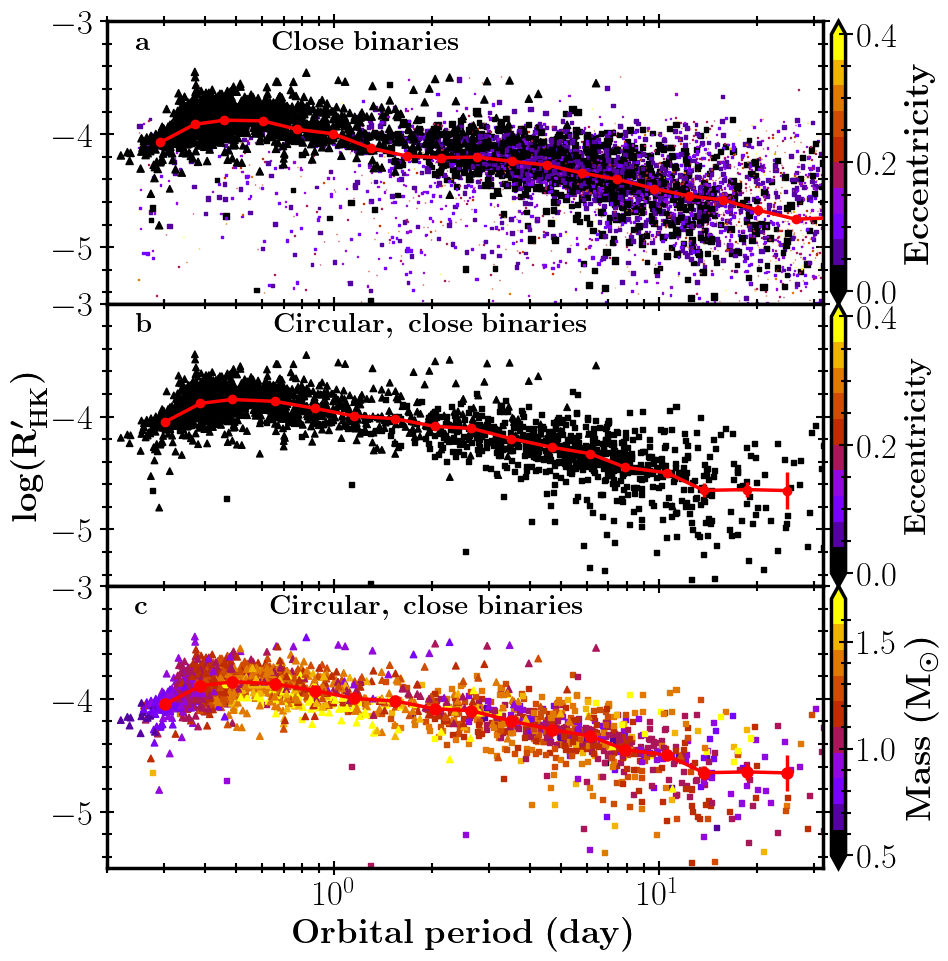

In [22]:
pthreshold = 0.3
iso = pd.read_csv("../Data/FinalCombinedData.csv")
iso = iso[iso.period.notna() &  (iso.logrRprimehk.notna())].reset_index(drop=True)
iso = iso[iso.teff.between(4000, 7000)].reset_index(drop=True)
iso.loc[:, "massfunc"] = kepler.massFunc(K=iso.K1, P=iso.period, e=iso.eccentricity)

# the trend does not change if restricted to 4000-6500K
# iso = iso[iso.teff.between(4000, 6500)].reset_index(drop=True) 

x = np.log10(iso.period.values)
y = iso.logrRprimehk.values
stat_bin_rhk = kepler.bin(x=x, y=y, bins=np.linspace(-0.6, 1.8, 23), suffixes=["P", "S"], LdivideN=True)
stat_bin_rhk = stat_bin_rhk.apply(pd.to_numeric)
stat_bin_rhk = stat_bin_rhk[(-2<stat_bin_rhk.median_P)&(stat_bin_rhk.median_P<1.7)&(stat_bin_rhk.N>10)]

# plot Prot vs Sindex
fig, ax = plt.subplots(3,1, figsize=(11, 11), sharex=True, sharey=True)
cmap = kepler.discretize_colormap("gnuplot", 10)
ax[0].errorbar(10**stat_bin_rhk.median_P, stat_bin_rhk.median_S, yerr=stat_bin_rhk.std_S, c="r", zorder=5, lw=2.5, marker="o")
ax[0].set_xscale("log")
cmap = kepler.discretize_colormap("gnuplot", 10)
cond = (iso.type.str.contains("SB"))
cb1 = ax[0].scatter(iso[cond].period, iso[cond].logrRprimehk, c=np.clip(iso[cond].eccentricity, 0, 0.4), vmax=0.4, s=10*np.exp(1-np.clip(iso[cond].eccentricity, 0, 0.4)*25), cmap=cmap, zorder=2, marker="s")
cond = (iso.type.str.contains("Ec"))
cb1 = ax[0].scatter(iso[cond].period, iso[cond].logrRprimehk, c=np.clip(iso[cond].eccentricity, 0, 0.4), vmax=0.4, s=10*np.exp(1-np.clip(iso[cond].eccentricity, 0, 0.4)*25), cmap=cmap, zorder=2, marker="^")
cbar = fig.colorbar(cb1, orientation="vertical", extend='both', pad=0.01)
cbar.set_label(r"$\boldsymbol{\rm{Eccentricity}}$")

x = np.log10(iso[(iso.eccentricity<0.03)].period.values)
y = iso[(iso.eccentricity<0.03)].logrRprimehk.values
stat_bin_rhk = kepler.bin(x=x, y=y, bins=np.linspace(-0.6, 1.45, 18), suffixes=["P", "S"], LdivideN=True)
stat_bin_rhk = stat_bin_rhk.apply(pd.to_numeric)
stat_bin_rhk = stat_bin_rhk[(-2<stat_bin_rhk.median_P)&(stat_bin_rhk.median_P<1.7)&(stat_bin_rhk.N>10)]
ax[1].errorbar(10**stat_bin_rhk.median_P, stat_bin_rhk.median_S, yerr=stat_bin_rhk.std_S, c="r", zorder=5, lw=2.5, marker="o")
cond = (iso.type.str.contains("SB")) & (iso.eccentricity<0.03)
cb1 = ax[1].scatter(iso[cond].period, iso[cond].logrRprimehk, c=np.clip(iso[cond].eccentricity, 0, 0.4), vmax=0.4, s=13, cmap=cmap, zorder=2, marker="s")
cond = (iso.type.str.contains("Ec")) & (iso.eccentricity<0.03)
cb1 = ax[1].scatter(iso[cond].period, iso[cond].logrRprimehk, c=np.clip(iso[cond].eccentricity, 0, 0.4), vmax=0.4, s=22, cmap=cmap, zorder=2, marker="^")
cbar = fig.colorbar(cb1, orientation="vertical", extend='both', pad=0.01)
cbar.set_label(r"$\boldsymbol{\rm{Eccentricity}}$", fontsize=22)
ax[1].set_ylabel(r"$\boldsymbol{\rm \log (R'_{HK})}$")
ax[1].set_xscale("log")

cond = (iso.type.str.contains("SB")) & (iso.eccentricity<0.03)
cb1 = ax[2].scatter(iso[cond].period, iso[cond].logrRprimehk, c=iso[cond].iso_mass, vmin=0.5, vmax=1.7, s=13, cmap=cmap, zorder=2, marker="s")
cond = (iso.type.str.contains("Ec")) & (iso.eccentricity<0.03)
cb2 = ax[2].scatter(iso[cond].period, iso[cond].logrRprimehk, c=iso[cond].iso_mass, vmin=0.5, vmax=1.7, s=22, cmap=cmap, zorder=2, marker="^")
x = np.log10(iso[(iso.eccentricity<0.03)].period.values)
y = iso[(iso.eccentricity<0.03)].logrRprimehk.values
stat_bin_rhk = kepler.bin(x=x, y=y, bins=np.linspace(-0.6, 1.45, 18), suffixes=["P", "S"], LdivideN=True)
stat_bin_rhk = stat_bin_rhk.apply(pd.to_numeric)
stat_bin_rhk = stat_bin_rhk[(-2<stat_bin_rhk.median_P)&(stat_bin_rhk.median_P<1.7)&(stat_bin_rhk.N>10)]
ax[2].errorbar(10**stat_bin_rhk.median_P, stat_bin_rhk.median_S, yerr=stat_bin_rhk.std_S, c="r", zorder=5, lw=2.5, ms=8, marker="o")
# cax = fig.add_axes([0.91, 0.12, 0.025, 0.75])  # Adjust these values to position the color bar
cbar = fig.colorbar(cb2, orientation="vertical", extend='both', pad=0.01)
cbar.set_label(r"$\boldsymbol{\rm{Mass~(M_{\odot})}}$")
ax[2].set_xlabel(r"$\boldsymbol{\rm Orbital~period~(day)}$")
ax[2].set_xlim(0.2, 32)
ax[2].set_ylim(-5.5, -3.0)
ax[2].set_xscale("log")
plt.subplots_adjust(hspace=0.0)
kepler.figure_annotation([ax[0]], text=[r"$\boldsymbol{\rm a~~~~~~~~~~~~~~Close~binaries}$", r"$\boldsymbol{\rm b}$"], fontsize=20, coords=[0.04, 0.90])
kepler.figure_annotation([ax[1]], text=[r"$\boldsymbol{\rm b~~~~~~~~~~~~~~Circular,~close~binaries}$", r"$\boldsymbol{\rm b}$"], fontsize=20, coords=[0.04, 0.90])
kepler.figure_annotation([ax[2]], text=[r"$\boldsymbol{\rm c~~~~~~~~~~~~~~Circular,~close~binaries}$", r"$\boldsymbol{\rm b}$"], fontsize=20, coords=[0.04, 0.90])
plt.savefig("../Figures/ProtlogRHKMassEccentricity.jpg", bbox_inches="tight", dpi=400)
plt.savefig("../Figures/ProtlogRHKMassEccentricity.pdf", bbox_inches="tight")


median fill factor error for primary: 0.002
median fill factor error for secondary: 0.001
Number of eclipsing binaries with eccentricity<0.03: 1348
number of eclipsing binaries with logP<0: 1165
number of spectroscopic binaries with logP<0: 0
ratio of EC/(SB+EC): 1.000
number of eclipsing binaries in common envelope and with logP<0: 968
ratio of ContEC/(EC): 0.831
number of eclipsing binaries in semi-contact logP<0: 113
ratio of SemiCont/(EC): 0.097
number of eclipsing binaries that are detach logP<0: 84
ratio of detach/(EC): 0.072


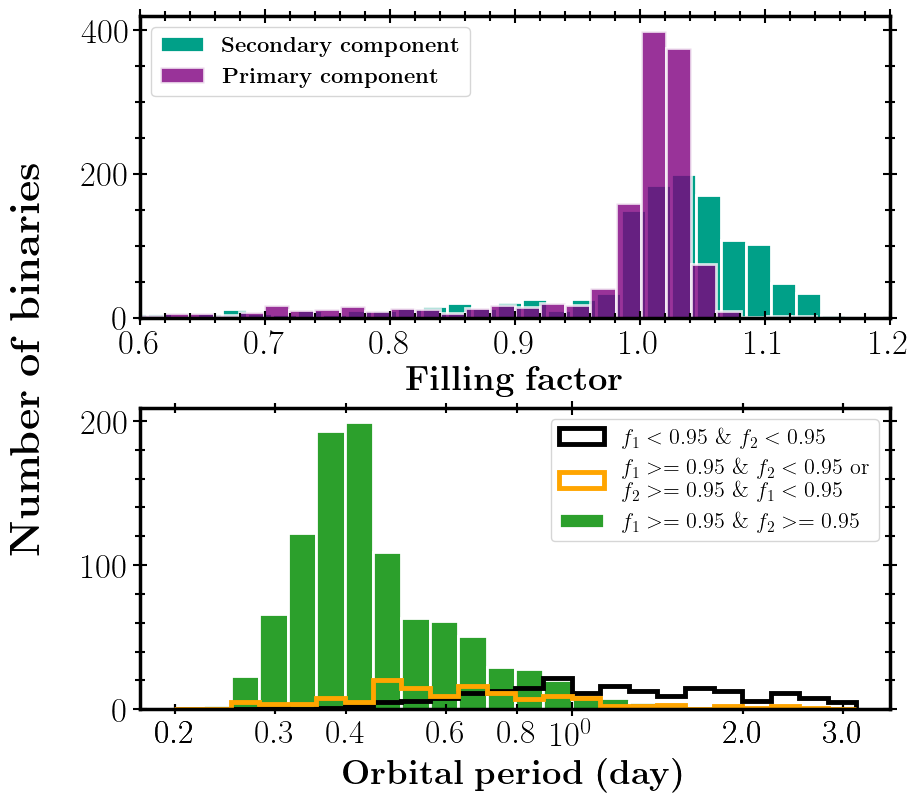

In [ ]:
iso = pd.read_csv("../Data/FinalCombinedData.csv")
iso = iso[iso.period.notna() &  (iso.logrRprimehk.notna())].reset_index(drop=True)
iso = iso[iso.teff.between(4000, 7000)].reset_index(drop=True)
iso.loc[:, "massfunc"] = kepler.massFunc(K=iso.K1, P=iso.period, e=iso.eccentricity)
iso=iso[iso.f1.notna() | iso.f2.notna()].reset_index(drop=True)

iso = iso[iso.eccentricity<0.03].reset_index(drop=True)
print(f"median fill factor error for primary: {iso[iso.type.str.contains('Ec')].f1err.median():.3f}")
print(f"median fill factor error for secondary: {iso[iso.type.str.contains('Ec')].f2err.median():.3f}")
print(f"Number of eclipsing binaries with eccentricity<0.03: {len(iso)}")

nEC = len(iso[iso.type.str.contains('Ec') &  (np.log10(iso.period)<0)])
nSB = len(iso[iso.type.str.contains('SB') &  (np.log10(iso.period)<0)])
print(f"number of eclipsing binaries with logP<0: {nEC}")
print(f"number of spectroscopic binaries with logP<0: {nSB}")
print(f'ratio of EC/(SB+EC): {nEC/(nEC+nSB):.3f}')

ContEC = (iso.f1>0.95) & (iso.f2>0.95) 
nContEC = len(iso[ContEC & iso.type.str.contains('Ec') & (np.log10(iso.period)<0)])
print(f"number of eclipsing binaries in common envelope and with logP<0: {nContEC}")
print(f'ratio of ContEC/(EC): {nContEC/(nEC):.3f}')

SemiCont = (((iso.f1>0.95) & (iso.f2<0.95)) | ((iso.f2>0.95) & (iso.f1<0.95))) 
nSemiontEC = len(iso[SemiCont & iso.type.str.contains('Ec') & (np.log10(iso.period)<0)])
print(f"number of eclipsing binaries in semi-contact logP<0: {nSemiontEC}")
print(f'ratio of SemiCont/(EC): {nSemiontEC/(nEC):.3f}')

detach = ((iso.f1<0.95) & (iso.f2<0.95))
ndetach = len(iso[detach & iso.type.str.contains('Ec') & (np.log10(iso.period)<0)])
print(f"number of eclipsing binaries that are detach logP<0: {ndetach}")
print(f'ratio of detach/(EC): {ndetach/(nEC):.3f}')


fig, ax = plt.subplots(2,1,figsize=(10,9))
ax[0].minorticks_on()
ax[0].hist(iso[iso.type.str.contains("Ec")].f2, bins=50, histtype="bar", lw=2.0, label=r"$\boldsymbol{\rm Secondary~component}$", color="#00A088", ec="w")
ax[0].hist(iso[iso.type.str.contains("Ec")].f1, bins=45, ec="w", histtype="bar", lw=2.0, label=r"$\boldsymbol{\rm Primary~component}$", color="purple", alpha=0.8)
ax[0].set_xlabel(r"$\boldsymbol{\rm Filling~factor}$")
ax[0].set_xlim(0.6, 1.2)
ax[0].legend(fontsize=16, loc="upper left")
ax[1].minorticks_on()

# define bins in log scale
bins = np.logspace(-0.7, 0.5, 25)
ax[1].hist(iso[detach].period, bins=bins, edgecolor="k", histtype="step", lw=3.5, label=r"$f_1<0.95~\&~f_2<0.95$")
ax[1].hist(iso[SemiCont].period, bins=bins, edgecolor="orange", histtype="step", lw=3.5, label=r"$f_1>=0.95~\&~f_2<0.95$" + r"$\mathrm{~or}$" + "\n" + r"$f_2>=0.95~\&~f_1<0.95$")
ax[1].hist(iso[ContEC].period, bins=bins, edgecolor="w", lw=2.0, label=r"$f_1>=0.95~\&~f_2>=0.95$")
ax[1].legend(fontsize=16, loc="upper right")
ax[1].set_xlabel(r"$\boldsymbol{\rm Orbital~period~(day)}$")
fig.supylabel(r"$\boldsymbol{\rm Number~of~binaries}$")
ax[1].set_xscale("log")

# add given minor tick labels.
minor_ticks = [0.2, 0.3, 0.4, 0.6, 0.8, 2, 3]
ax[1].xaxis.set_minor_locator(LogLocator(base=10.0, subs=minor_ticks))
ax[1].xaxis.set_minor_formatter(LogFormatter(base=10.0))
ax[1].tick_params(axis="x", which="minor", labelsize=24)
ax[1].xaxis.set_minor_formatter(MinorLogFormatter(base=10))

plt.subplots_adjust(hspace=0.3, left=0.15)
plt.savefig("../Figures/CloseContactBinaries.jpg", bbox_inches="tight", dpi=300)
plt.savefig("../Figures/CloseContactBinaries.pdf", bbox_inches="tight")
